# MAGNET training inputs — two real pipelines

There are **two different encoder-input catalogs**, not three copies of the same file:

| Pipeline | Models | On-disk catalog | `target_catalog` filter | Encoder sees sub-Mc? | Extra columns |
|----------|--------|-----------------|-------------------------|----------------------|---------------|
| **Native Hauksson** | Paper (Berman et al. 2026), `Hauksson_recreate` | `hauksson.csv` | `return_entire_catalog_criterion` → **all events** | **Yes** (~234k) | strike, dip, rake, … |
| **ETAS continuation** | `model_4c0643af` | `magnet_catalog_prepared.csv` | `is_in_magnitude_range` → **M ≥ 2.4 only** | **No** | time, lat, lon, mag, depth only |

Paper and Recreate share the **same** native encoder catalog (plots are duplicated in the config table only).

**Supervised queries** (all pipelines): events with **M ≥ Mc** inside each train/val/test split (Mc ≈ 2.4).


In [1]:
%matplotlib inline
from __future__ import annotations

import re
import sys
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / "runnable_code").is_dir() and (REPO_ROOT.parent / "runnable_code").is_dir():
    REPO_ROOT = REPO_ROOT.parent

EQ_MAG_ROOT = Path("/a/home/cc/students/csguests/neriberman/Repos/eq_mag_prediction/eq_mag_prediction")
EQ_MAG_CLEAN = Path("/a/home/cc/students/csguests/neriberman/Repos/eq_mag_prediction/eq_mag_prediction_clean")
if str(EQ_MAG_CLEAN) not in sys.path:
    sys.path.insert(0, str(EQ_MAG_CLEAN))

from eq_mag_prediction.utilities import catalog_analysis

CONTINUATION_OUTPUT = REPO_ROOT / "outputs/hauksson_magnet_sample_continuation_models"
CONTINUATION_MODEL_DIR = (
    CONTINUATION_OUTPUT
    / "magnet/model_4c0643af3ff12d6579647cee0646a19101a573b7/_repetition_0"
)

# --- Actual catalog files on disk (different paths, different content) ---
NATIVE_CATALOG_PATH = EQ_MAG_ROOT / "results/catalogs/ingested/hauksson.csv"
ETAS_CONVERTED_PATH = REPO_ROOT / "input_data/etas_converted_hauksson.csv"
CONTINUATION_CATALOG_PATH = CONTINUATION_OUTPUT / "magnet_generated/magnet_catalog_prepared.csv"

GIN_PATHS = {
    "paper": EQ_MAG_CLEAN / "eq_mag_prediction/forecasting/configs/magnitude_prediction/hauksson.gin",
    "recreate": EQ_MAG_ROOT / "results/trained_models/Hauksson_recreate/config.gin",
    "continuation": CONTINUATION_MODEL_DIR / "config.gin",
}

POLYGON_PATH = REPO_ROOT / "input_data/hauksson_polygon_from_notebook.npy"
FIGURE_DIR = REPO_ROOT / "notebooks/figures/magnet_training_catalog_comparison"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
DO_SAVE = False

PAPER_SPLITS = {
    "train_start": pd.Timestamp("1981-01-01 00:00:00", tz="UTC"),
    "val_start": pd.Timestamp("2009-02-03 12:39:39", tz="UTC"),
    "test_start": pd.Timestamp("2016-05-23 23:05:46", tz="UTC"),
    "test_end_paper": pd.Timestamp("2019-12-31 22:48:20", tz="UTC"),
}
CONTINUATION_TEST_END = pd.Timestamp("2020-01-01 00:00:00", tz="UTC")

MC_QUERY_NATIVE = 2.4  # paper SoCal; also MBS estimate on train native catalog

PIPELINE_NATIVE = {
    "key": "native",
    "title": "Paper + Hauksson_recreate\n(native Hauksson, ALL events)",
    "catalog_path": NATIVE_CATALOG_PATH,
    "encoder_filter": "all_events",
    "mc_query": MC_QUERY_NATIVE,
    "test_end": PAPER_SPLITS["test_end_paper"],
    "moment_angles": True,
}

PIPELINE_CONTINUATION = {
    "key": "continuation",
    "title": "Continuation model_4c0643af\n(ETAS-prepared, M >= 2.4 only)",
    "catalog_path": CONTINUATION_CATALOG_PATH,
    "encoder_filter": "min_mag_2.4",
    "mc_query": 2.4,
    "test_end": CONTINUATION_TEST_END,
    "moment_angles": False,
}

PIPELINES = [PIPELINE_NATIVE, PIPELINE_CONTINUATION]

MODEL_CONFIG_ROWS = [
    {"model": "Paper Hauksson", "pipeline": "native", "gin": GIN_PATHS["paper"]},
    {"model": "Hauksson_recreate", "pipeline": "native", "gin": GIN_PATHS["recreate"]},
    {"model": "Continuation model_4c0643af", "pipeline": "continuation", "gin": GIN_PATHS["continuation"]},
]

print("REPO_ROOT =", REPO_ROOT)


REPO_ROOT = /home/neriberman/Repos/etas


In [2]:
def parse_gin(path: Path) -> dict:
    text = path.read_text() if path.is_file() else ""
    out: dict = {}

    m = re.search(r"earthquake_criterion\s*=\s*@(\w+)", text)
    out["earthquake_criterion"] = m.group(1) if m else "?"

    m = re.search(r"minimum_magnitude\s*=\s*([\d.]+)", text)
    if m:
        out["minimum_magnitude"] = float(m.group(1))

    m = re.search(r"use_moment_angles\s*=\s*(True|False)", text)
    if m:
        out["use_moment_angles"] = m.group(1) == "True"

    m = re.search(r"_mock_earthquake\.add_angles\s*=\s*(True|False)", text)
    if m:
        out["add_angles"] = m.group(1) == "True"

    m = re.search(r"CatalogDomain\.user_magnitude_threshold\s*=\s*([\d.]+|None)", text)
    if m and m.group(1) != "None":
        out["user_magnitude_threshold"] = float(m.group(1))

    m = re.search(r"hauksson_dataframe\.csv_path\s*=\s*(.+)$", text, re.MULTILINE)
    if m:
        out["catalog_csv_path"] = m.group(1).strip().strip("'\"")

    for dotted, key in (
        ("train_and_evaluate_magnitude_prediction_model.epochs", "epochs"),
        ("train_and_evaluate_magnitude_prediction_model.batch_size", "batch_size"),
    ):
        m = re.search(rf"^{re.escape(dotted)}\s*=\s*(\d+)", text, re.MULTILINE)
        if m:
            out[key] = int(m.group(1))

    return out


def load_catalog(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)
    if pd.api.types.is_numeric_dtype(df["time"]) and df["time"].max() > 1e9:
        df["time"] = pd.to_datetime(df["time"], unit="s", utc=True)
    else:
        df["time"] = pd.to_datetime(df["time"], utc=True)
    return df.sort_values("time").reset_index(drop=True)


def assign_split(times: pd.Series, test_end: pd.Timestamp) -> pd.Series:
    out = pd.Series("outside", index=times.index, dtype=object)
    t = times.dt.tz_convert("UTC")
    out[(t >= PAPER_SPLITS["train_start"]) & (t < PAPER_SPLITS["val_start"])] = "train"
    out[(t >= PAPER_SPLITS["val_start"]) & (t < PAPER_SPLITS["test_start"])] = "validation"
    out[(t >= PAPER_SPLITS["test_start"]) & (t < test_end)] = "test"
    return out


def build_encoder_catalog(raw: pd.DataFrame, pipeline: dict) -> pd.DataFrame:
    if pipeline["encoder_filter"] == "all_events":
        return raw.copy()
    min_mag = float(pipeline.get("mc_query", 2.4))
    return raw[raw["magnitude"] >= min_mag].copy()


SPLIT_NAMES = ("train", "validation", "test")


def build_query_catalog(encoder_cat: pd.DataFrame, mc: float, test_end: pd.Timestamp) -> pd.DataFrame:
    """Supervised examples: M >= Mc inside train/val/test windows only."""
    q = encoder_cat[encoder_cat["magnitude"] >= mc].copy()
    q["split"] = assign_split(q["time"], test_end)
    return q[q["split"].isin(SPLIT_NAMES)].copy()


def event_key(df: pd.DataFrame) -> pd.Series:
    t = df["time"].dt.round("s").astype(str)
    return (
        t + "|" + df["latitude"].round(5).astype(str)
        + "|" + df["longitude"].round(5).astype(str)
        + "|" + df["magnitude"].round(3).astype(str)
    )


# Load catalogs from their actual paths
native_raw = load_catalog(NATIVE_CATALOG_PATH)
continuation_raw = load_catalog(CONTINUATION_CATALOG_PATH)
etas_raw = load_catalog(ETAS_CONVERTED_PATH) if ETAS_CONVERTED_PATH.is_file() else None

# Verify native Mc from train (MBS)
_train_native = native_raw[
    (native_raw["time"] >= PAPER_SPLITS["train_start"])
    & (native_raw["time"] < PAPER_SPLITS["val_start"])
]
_mbs_mc = float(catalog_analysis.estimate_completeness(_train_native["magnitude"].to_numpy(), method="MBS"))
PIPELINE_NATIVE["mc_query"] = _mbs_mc

pipeline_data = {}
for p in PIPELINES:
    raw = native_raw if p["key"] == "native" else continuation_raw
    enc = build_encoder_catalog(raw, p)
    qry = build_query_catalog(enc, p["mc_query"], p["test_end"])
    pipeline_data[p["key"]] = {
        "raw": raw,
        "encoder": enc,
        "query": qry,
        "columns": list(raw.columns),
        "n_sub_mc_encoder": int((enc["magnitude"] < p["mc_query"]).sum()),
    }

# Config table for all 3 named models
cfg_rows = []
for row in MODEL_CONFIG_ROWS:
    g = parse_gin(row["gin"])
    pk = row["pipeline"]
    pd_ = pipeline_data[pk]
    cfg_rows.append(
        {
            "model": row["model"],
            "pipeline": pk,
            "catalog_file": Path(g.get("catalog_csv_path", pd_["raw"].attrs.get("path", "?"))).name
            if isinstance(g.get("catalog_csv_path"), str)
            else (NATIVE_CATALOG_PATH.name if pk == "native" else CONTINUATION_CATALOG_PATH.name),
            "earthquake_criterion": g.get("earthquake_criterion"),
            "encoder_rows": len(pd_["encoder"]),
            "sub_Mc_in_encoder": pd_["n_sub_mc_encoder"],
            "query_rows": len(pd_["query"]),
            "Mc_queries": round(pd_["query"]["magnitude"].min(), 2) if len(pd_["query"]) else np.nan,
            "moment_angles": g.get("use_moment_angles", g.get("add_angles")),
            "user_Mc": g.get("user_magnitude_threshold"),
            "epochs": g.get("epochs"),
            "batch": g.get("batch_size"),
        }
    )

display(pd.DataFrame(cfg_rows).set_index("model"))

display(Markdown(
    f"**Native train-set Mc (MBS):** `{_mbs_mc:.3f}` | "
    f"**Native encoder rows:** {len(pipeline_data['native']['encoder']):,} "
    f"({pipeline_data['native']['n_sub_mc_encoder']:,} below Mc) | "
    f"**Continuation encoder rows:** {len(pipeline_data['continuation']['encoder']):,} (all >= 2.4)"
))


,pipeline,catalog_file,earthquake_criterion,encoder_rows,sub_Mc_in_encoder,query_rows,Mc_queries,moment_angles,user_Mc,epochs,batch
model,,,,,,,,,,,
Paper Hauksson,native,hauksson.csv,return_entire_catalog_criterion,266662,233940,31397,2.41,True,NaN,NaN,NaN
Hauksson_recreate,native,hauksson.csv,return_entire_catalog_criterion,266662,233940,31397,2.41,True,NaN,150.0,256.0
Continuation model_4c0643af,continuation,\,is_in_magnitude_range,33491,0,32136,2.40,False,2.4,150.0,256.0


**Native train-set Mc (MBS):** `2.400` | **Native encoder rows:** 266,662 (233,940 below Mc) | **Continuation encoder rows:** 33,491 (all >= 2.4)

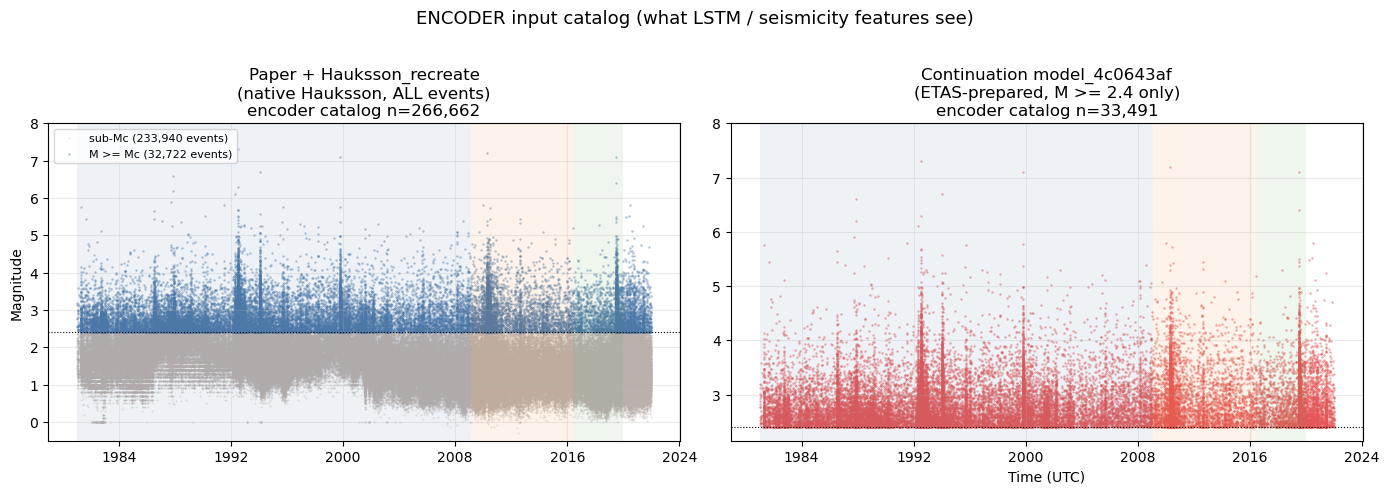

In [3]:
SPLIT_COLORS = {"train": "#4C78A8", "validation": "#F58518", "test": "#54A24B"}


def shade_splits(ax, test_end, alpha=0.09):
    for name, t0, t1 in (
        ("train", PAPER_SPLITS["train_start"], PAPER_SPLITS["val_start"]),
        ("validation", PAPER_SPLITS["val_start"], PAPER_SPLITS["test_start"]),
        ("test", PAPER_SPLITS["test_start"], test_end),
    ):
        ax.axvspan(t0, t1, color=SPLIT_COLORS[name], alpha=alpha, lw=0)


def plot_encoder_mag_vs_time():
    """ENCODER input: native ALL events vs continuation M>=2.4 ONLY."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.8), sharex=True)

    # --- Native: show sub-Mc vs sup-Mc ---
    ax = axes[0]
    enc = pipeline_data["native"]["encoder"]
    mc = PIPELINE_NATIVE["mc_query"]
    sub = enc["magnitude"] < mc
    ax.scatter(enc.loc[sub, "time"], enc.loc[sub, "magnitude"], s=2, c="#BAB0AC", alpha=0.35, linewidths=0,
               label=f"sub-Mc ({sub.sum():,} events)")
    ax.scatter(enc.loc[~sub, "time"], enc.loc[~sub, "magnitude"], s=3, c="#4C78A8", alpha=0.45, linewidths=0,
               label=f"M >= Mc ({(~sub).sum():,} events)")
    shade_splits(ax, PIPELINE_NATIVE["test_end"])
    ax.axhline(mc, color="k", ls=":", lw=0.8)
    ax.set_ylim(-0.5, 8)
    ax.set_ylabel("Magnitude")
    ax.set_title(f"{PIPELINE_NATIVE['title']}\nencoder catalog n={len(enc):,}")
    ax.legend(loc="upper left", fontsize=8)
    ax.grid(True, alpha=0.25)

    # --- Continuation: ONLY M>=2.4, no sub-Mc possible ---
    ax = axes[1]
    enc = pipeline_data["continuation"]["encoder"]
    mc = PIPELINE_CONTINUATION["mc_query"]
    ax.scatter(enc["time"], enc["magnitude"], s=3, c="#E45756", alpha=0.5, linewidths=0)
    shade_splits(ax, PIPELINE_CONTINUATION["test_end"])
    ax.axhline(mc, color="k", ls=":", lw=0.8)
    ax.set_ylim(mc - 0.25, 8)
    ax.set_title(f"{PIPELINE_CONTINUATION['title']}\nencoder catalog n={len(enc):,}")
    ax.grid(True, alpha=0.25)

    for ax in axes:
        ax.xaxis.set_major_locator(mdates.YearLocator(8))
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    axes[1].set_xlabel("Time (UTC)")
    fig.suptitle("ENCODER input catalog (what LSTM / seismicity features see)", y=1.02, fontsize=13)
    fig.tight_layout()
    if DO_SAVE:
        fig.savefig(FIGURE_DIR / "encoder_mag_vs_time_two_pipelines.png", dpi=160, bbox_inches="tight")
    plt.show()


plot_encoder_mag_vs_time()


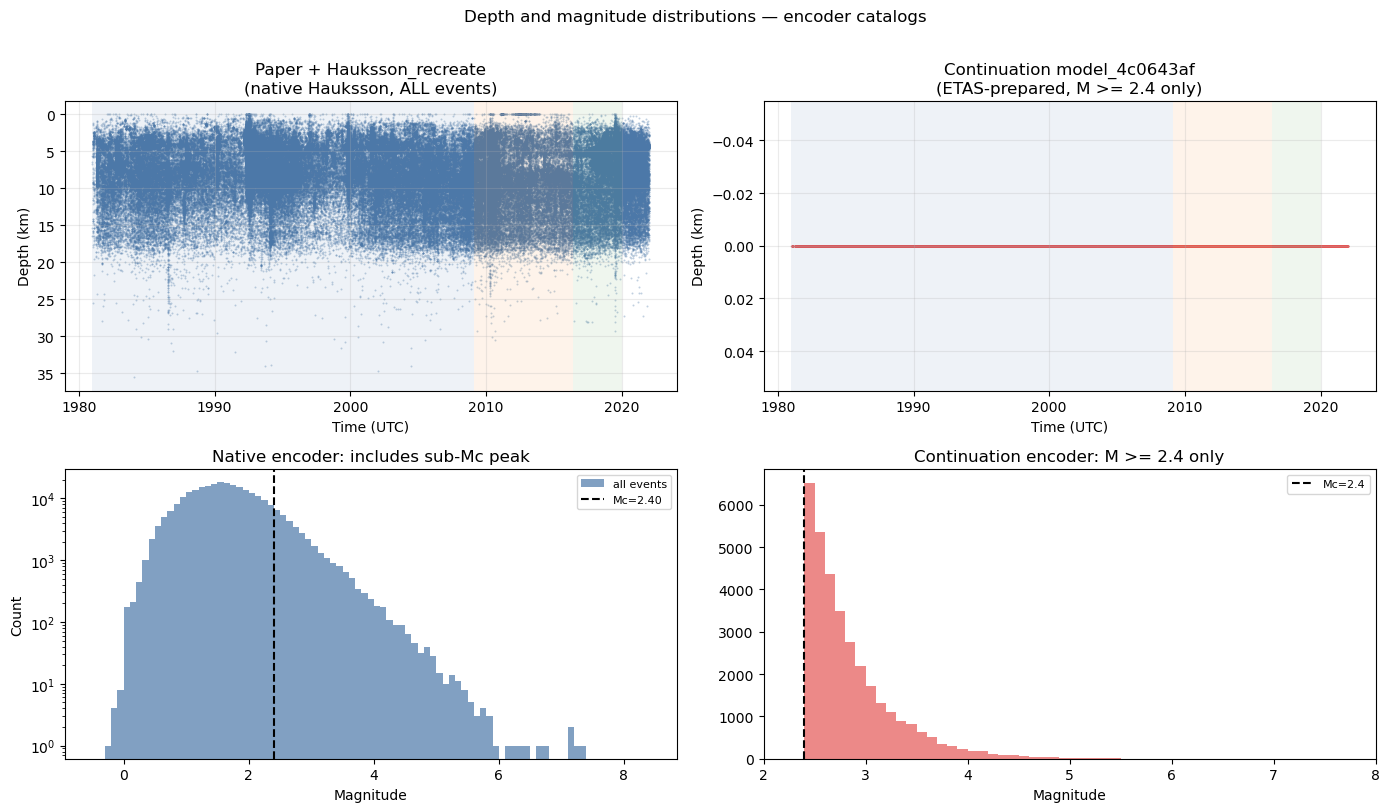

In [4]:
def plot_encoder_depth_and_hist():
    fig, axes = plt.subplots(2, 2, figsize=(14, 8))

    # depth vs time
    for col, (key, color) in enumerate((("native", "#4C78A8"), ("continuation", "#E45756"))):
        enc = pipeline_data[key]["encoder"]
        ax = axes[0, col]
        ax.scatter(enc["time"], enc["depth"] if "depth" in enc.columns else np.nan,
                   s=2, alpha=0.35, c=color, linewidths=0)
        shade_splits(ax, PIPELINES[col]["test_end"])
        ax.set_ylabel("Depth (km)")
        ax.set_title(PIPELINES[col]["title"])
        ax.grid(True, alpha=0.25)
        ax.invert_yaxis()

    # magnitude histogram (encoder)
    ax = axes[1, 0]
    enc = pipeline_data["native"]["encoder"]
    mc = PIPELINE_NATIVE["mc_query"]
    bins = np.arange(-0.5, 8.5, 0.1)
    ax.hist(enc["magnitude"], bins=bins, color="#4C78A8", alpha=0.7, label="all events")
    ax.axvline(mc, color="k", ls="--", label=f"Mc={mc:.2f}")
    ax.set_xlabel("Magnitude")
    ax.set_ylabel("Count")
    ax.set_title("Native encoder: includes sub-Mc peak")
    ax.legend(fontsize=8)
    ax.set_yscale("log")

    ax = axes[1, 1]
    enc = pipeline_data["continuation"]["encoder"]
    ax.hist(enc["magnitude"], bins=bins, color="#E45756", alpha=0.7)
    ax.axvline(2.4, color="k", ls="--", label="Mc=2.4")
    ax.set_xlabel("Magnitude")
    ax.set_title("Continuation encoder: M >= 2.4 only")
    ax.set_xlim(2.0, 8)
    ax.legend(fontsize=8)

    for ax in axes[0, :]:
        ax.xaxis.set_major_locator(mdates.YearLocator(10))
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
        ax.set_xlabel("Time (UTC)")

    fig.suptitle("Depth and magnitude distributions — encoder catalogs", y=1.01)
    fig.tight_layout()
    if DO_SAVE:
        fig.savefig(FIGURE_DIR / "encoder_depth_mag_hist.png", dpi=160, bbox_inches="tight")
    plt.show()


plot_encoder_depth_and_hist()


/tmp/ipykernel_2326864/1730385570.py:66: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


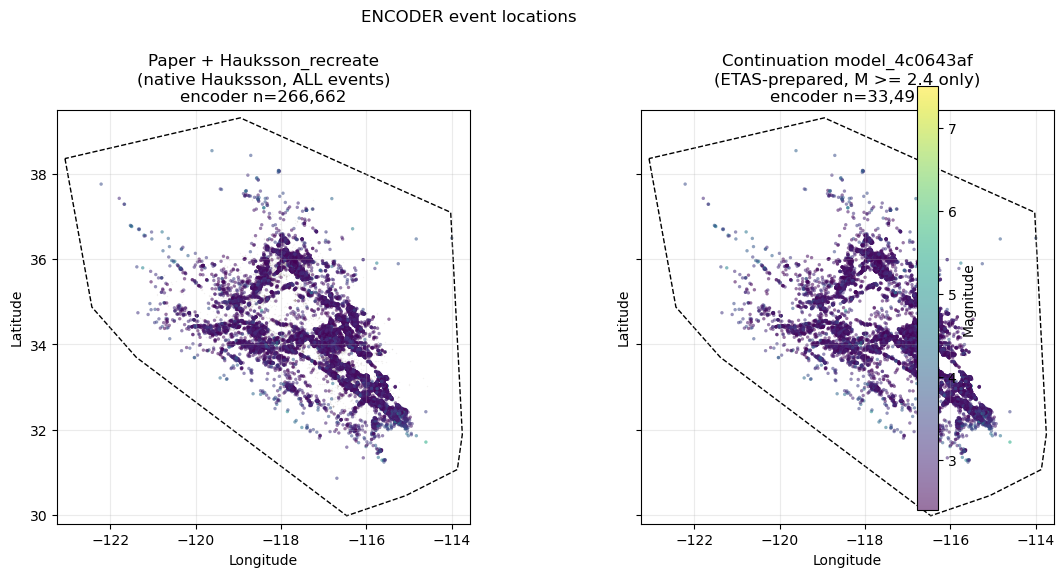

In [5]:
def load_study_polygon_lonlat(path: Path) -> np.ndarray | None:
    """Return polygon vertices as (lon, lat); file stores (lat, lon) like ETAS shape_coords."""
    if not path.is_file():
        return None
    latlon = np.load(path)
    return np.column_stack([latlon[:, 1], latlon[:, 0]])


def map_axis_limits(encoders: list[pd.DataFrame], poly_lonlat: np.ndarray | None, pad_frac=0.02):
  lons = np.concatenate([e["longitude"].to_numpy() for e in encoders])
  lats = np.concatenate([e["latitude"].to_numpy() for e in encoders])
  lon_min, lon_max = float(lons.min()), float(lons.max())
  lat_min, lat_max = float(lats.min()), float(lats.max())
  if poly_lonlat is not None:
      lon_min = min(lon_min, float(poly_lonlat[:, 0].min()))
      lon_max = max(lon_max, float(poly_lonlat[:, 0].max()))
      lat_min = min(lat_min, float(poly_lonlat[:, 1].min()))
      lat_max = max(lat_max, float(poly_lonlat[:, 1].max()))
  pad_lon = (lon_max - lon_min) * pad_frac
  pad_lat = (lat_max - lat_min) * pad_frac
  return lon_min - pad_lon, lon_max + pad_lon, lat_min - pad_lat, lat_max + pad_lat


def plot_encoder_locations():
    from matplotlib.patches import Polygon as MplPolygon

    poly_lonlat = load_study_polygon_lonlat(POLYGON_PATH)
    encoders = [pipeline_data[p["key"]]["encoder"] for p in PIPELINES]
    x0, x1, y0, y1 = map_axis_limits(encoders, poly_lonlat)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5.5), sharex=True, sharey=True)
    sc = None

    for ax, p in zip(axes, PIPELINES):
        enc = pipeline_data[p["key"]]["encoder"]
        mc = p["mc_query"]
        if p["key"] == "native":
            sub = enc["magnitude"] < mc
            ax.scatter(
                enc.loc[sub, "longitude"], enc.loc[sub, "latitude"],
                s=1, c="#BAB0AC", alpha=0.15, linewidths=0, rasterized=True,
            )
            sc = ax.scatter(
                enc.loc[~sub, "longitude"], enc.loc[~sub, "latitude"],
                c=enc.loc[~sub, "magnitude"], s=6, cmap="viridis", alpha=0.55,
                vmin=mc, vmax=7.5, linewidths=0, rasterized=True,
            )
        else:
            sc = ax.scatter(
                enc["longitude"], enc["latitude"], c=enc["magnitude"], s=6,
                cmap="viridis", alpha=0.55, vmin=mc, vmax=7.5, linewidths=0, rasterized=True,
            )
        if poly_lonlat is not None:
            ax.add_patch(MplPolygon(poly_lonlat, fill=False, edgecolor="k", lw=1, ls="--"))
        ax.set_xlim(x0, x1)
        ax.set_ylim(y0, y1)
        ax.set_aspect("equal", adjustable="box")
        ax.set_xlabel("Longitude")
        ax.set_ylabel("Latitude")
        ax.set_title(f"{p['title']}\nencoder n={len(enc):,}")
        ax.grid(True, alpha=0.25)

    cbar = fig.colorbar(sc, ax=axes.ravel().tolist(), fraction=0.035, pad=0.02)
    cbar.set_label("Magnitude")
    fig.suptitle("ENCODER event locations", y=1.02)
    fig.tight_layout()
    if DO_SAVE:
        fig.savefig(FIGURE_DIR / "encoder_locations.png", dpi=160, bbox_inches="tight")
    plt.show()


plot_encoder_locations()


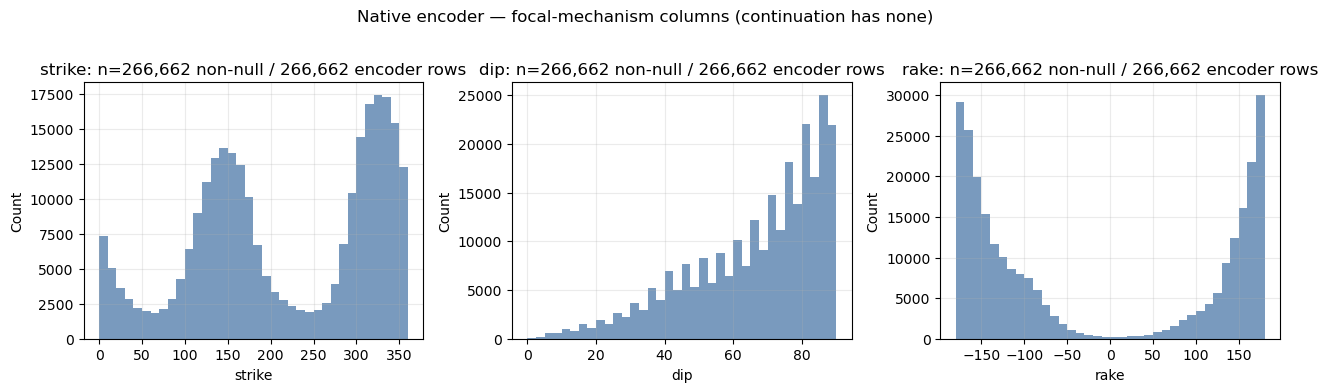

In [6]:
def plot_native_moment_angles():
    """Native pipeline only: strike/dip/rake columns absent from continuation CSV."""
    enc = pipeline_data["native"]["encoder"]
    if not {"strike", "dip", "rake"}.issubset(enc.columns):
        print("No moment-angle columns in native catalog")
        return
    fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
    for ax, col in zip(axes, ("strike", "dip", "rake")):
        vals = enc[col].dropna()
        ax.hist(vals, bins=36, color="#4C78A8", alpha=0.75)
        ax.set_xlabel(col)
        ax.set_ylabel("Count")
        ax.set_title(f"{col}: n={len(vals):,} non-null / {len(enc):,} encoder rows")
        ax.grid(True, alpha=0.25)
    fig.suptitle("Native encoder — focal-mechanism columns (continuation has none)", y=1.02)
    fig.tight_layout()
    if DO_SAVE:
        fig.savefig(FIGURE_DIR / "native_moment_angles.png", dpi=160, bbox_inches="tight")
    plt.show()


plot_native_moment_angles()


In [7]:
# Column / feature availability (not just magnitude)
native_cols = set(pipeline_data["native"]["raw"].columns)
cont_cols = set(pipeline_data["continuation"]["raw"].columns)

col_rows = []
for c in sorted(native_cols | cont_cols):
    col_rows.append({
        "column": c,
        "native_hauksson": c in native_cols,
        "continuation_prepared": c in cont_cols,
    })
display(pd.DataFrame(col_rows).set_index("column"))

display(Markdown("**Moment angles:** native pipeline uses strike/dip/rake (`use_moment_angles=True`); continuation sets `use_moment_angles=False` and the prepared CSV has no FM columns."))

# Event-level identity diff between native encoder (all) and continuation encoder (filtered + different file)
native_enc = pipeline_data["native"]["encoder"]
cont_enc = pipeline_data["continuation"]["encoder"]
k_native = set(event_key(native_enc))
k_cont = set(event_key(cont_enc))
only_native = k_native - k_cont
only_cont = k_cont - k_native

display(pd.DataFrame([
    {"set": "events in native encoder only", "count": len(only_native)},
    {"set": "events in continuation encoder only", "count": len(only_cont)},
    {"set": "shared (same time/lat/lon/mag)", "count": len(k_native & k_cont)},
]).set_index("set"))

# Show magnitude range actually present
display(pd.DataFrame({
    "pipeline": ["native encoder", "continuation encoder"],
    "mag_min": [native_enc["magnitude"].min(), cont_enc["magnitude"].min()],
    "mag_max": [native_enc["magnitude"].max(), cont_enc["magnitude"].max()],
    "depth_min": [native_enc["depth"].min() if "depth" in native_enc else np.nan,
                  cont_enc["depth"].min() if "depth" in cont_enc else np.nan],
    "depth_max": [native_enc["depth"].max() if "depth" in native_enc else np.nan,
                  cont_enc["depth"].max() if "depth" in cont_enc else np.nan],
}).set_index("pipeline"))


,native_hauksson,continuation_prepared
column,,
day,True,False
depth,True,True
dip,True,False
event_id,True,False
hour,True,False
latitude,True,True
longitude,True,True
magnitude,True,True
minute,True,False


**Moment angles:** native pipeline uses strike/dip/rake (`use_moment_angles=True`); continuation sets `use_moment_angles=False` and the prepared CSV has no FM columns.

,count
set,
events in native encoder only,233165
events in continuation encoder only,0
shared (same time/lat/lon/mag),33491


,mag_min,mag_max,depth_min,depth_max
pipeline,,,,
native encoder,-0.29,7.3,0.0,35.54
continuation encoder,2.40,7.3,0.0,0.00


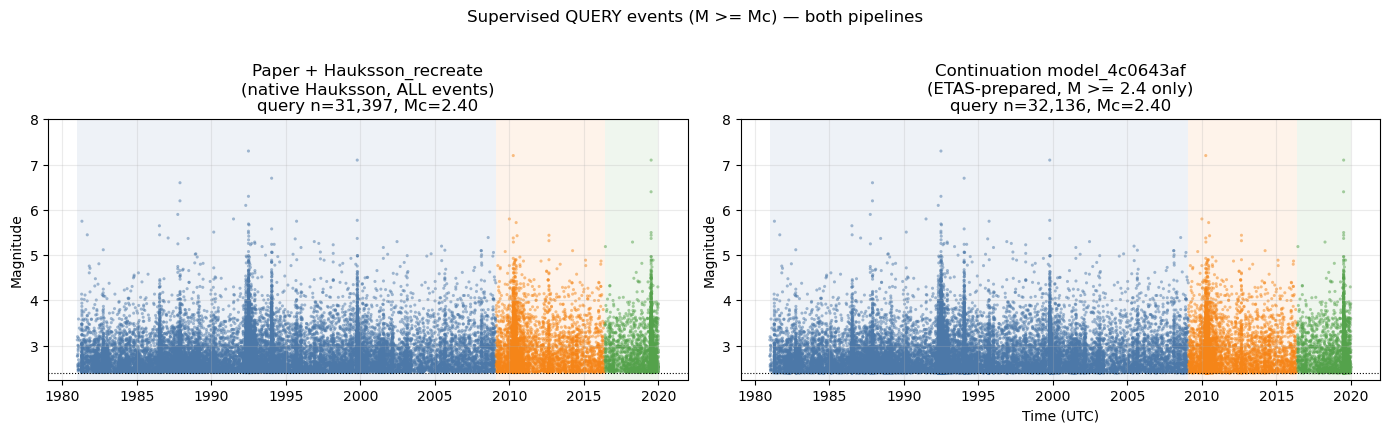

In [8]:
def plot_query_mag_vs_time():
    """Supervised queries: M >= Mc inside splits (different underlying event sets)."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.2), sharex=True)
    for ax, p in zip(axes, PIPELINES):
        q = pipeline_data[p["key"]]["query"]
        colors = q["split"].map(SPLIT_COLORS).fillna("#999999")
        ax.scatter(q["time"], q["magnitude"], c=colors, s=5, alpha=0.5, linewidths=0)
        shade_splits(ax, p["test_end"])
        ax.axhline(p["mc_query"], color="k", ls=":", lw=0.8)
        ax.set_ylim(p["mc_query"] - 0.15, 8)
        ax.set_ylabel("Magnitude")
        ax.set_title(f"{p['title']}\nquery n={len(q):,}, Mc={p['mc_query']:.2f}")
        ax.grid(True, alpha=0.25)
    axes[1].set_xlabel("Time (UTC)")
    fig.suptitle("Supervised QUERY events (M >= Mc) — both pipelines", y=1.02)
    fig.tight_layout()
    plt.show()


plot_query_mag_vs_time()


### Summary

- **Do not compare three identical mag-vs-time panels.** Paper and Recreate share one native encoder catalog; only the continuation model uses a **different file** pre-filtered to **M ≥ 2.4**.
- **Encoder plots** must show the sub-Mc cloud for native (grey) and its absence for continuation.
- **Queries** are more similar (all M ≥ Mc) but come from different underlying event sets (~6+ row differences after ETAS conversion).
